# Phase 1 EDNet-KT Smoke Test

MSc Dissertation: A Comparative Study of Knowledge Tracing Models — BKT, DKT and SAKT on EDNet-KT1.

This notebook builds the Phase 1 pipeline from scratch:

1. Set up the environment.
2. Load EDNet-KT1 data.
3. Preprocess interactions and question metadata.
4. Create a small student-level smoke-test subset.
5. Train and evaluate a BKT baseline.
6. Prepare the structure for DKT and SAKT smoke tests.

The purpose of this notebook is not final model performance. It is to verify that the full pipeline works end-to-end.

In [42]:
%pip install -q pyBKT scikit-learn pandas numpy matplotlib


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [43]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")


Random seed set to 42


In [44]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"          
CONTENT_DATA_DIR = DATA_DIR / "contents"  

print("Project root:", PROJECT_ROOT)
print("User CSV folder:", RAW_DATA_DIR)
print("Content metadata folder:", CONTENT_DATA_DIR)


Project root: /Users/tolulopesoetan/Desktop/msc_kt_ednet
User CSV folder: /Users/tolulopesoetan/Desktop/msc_kt_ednet/data/raw
Content metadata folder: /Users/tolulopesoetan/Desktop/msc_kt_ednet/data/contents


In [45]:
CONFIG = {
    "seed": SEED,
    "smoke_test_n_students": 100,  
    "train_size": 0.8,
    "dataset_name": "EDNet-KT1",
    "user_column": "user_id",
    "question_column": "question_id",
    "target_column": "is_correct",
    "skill_column": "skill_name",
    "min_interactions_per_skill": 10,
}

CONFIG


{'seed': 42,
 'smoke_test_n_students': 100,
 'train_size': 0.8,
 'dataset_name': 'EDNet-KT1',
 'user_column': 'user_id',
 'question_column': 'question_id',
 'target_column': 'is_correct',
 'skill_column': 'skill_name',
 'min_interactions_per_skill': 10}

In [46]:
# Find EDNet-KT1 user CSV files in data/raw.
user_csv_files = sorted([
    p for p in RAW_DATA_DIR.rglob("*.csv")
    if p.name.lower().startswith("u") and p.stem[1:].isdigit()
])

print(f"Found {len(user_csv_files)} user CSV file(s) in data/raw.")

QUESTION_METADATA_PATH = CONTENT_DATA_DIR / "questions.csv"




Found 784309 user CSV file(s) in data/raw.


In [47]:
# Preview one user interaction file.
if len(user_csv_files) == 0:
    raise FileNotFoundError("No user CSV files found. Check that files like u1.csv are inside data/raw.")

sample_user_file = user_csv_files[0]
sample_user_df = pd.read_csv(sample_user_file)

print("Sample user file:", sample_user_file.relative_to(PROJECT_ROOT))
print("Shape:", sample_user_df.shape)
print("Columns:")
print(list(sample_user_df.columns))

display(sample_user_df.head())


Sample user file: data/raw/u1.csv
Shape: (1082, 5)
Columns:
['timestamp', 'solving_id', 'question_id', 'user_answer', 'elapsed_time']


,timestamp,solving_id,question_id,user_answer,elapsed_time
0,1565096190868,1,q5012,b,38000
1,1565096221062,2,q4706,c,24000
2,1565096293432,3,q4366,b,68000
3,1565096339668,4,q4829,a,42000
4,1565096401774,5,q6528,b,59000


In [48]:
# Load and preview questions.csv.
if not QUESTION_METADATA_PATH.exists():
    raise FileNotFoundError("questions.csv was not found in data/contents")

questions_df = pd.read_csv(QUESTION_METADATA_PATH)

print("Question metadata shape:", questions_df.shape)
print("Columns:")
print(list(questions_df.columns))

display(questions_df.head())


Question metadata shape: (13169, 7)
Columns:
['question_id', 'bundle_id', 'explanation_id', 'correct_answer', 'part', 'tags', 'deployed_at']


,question_id,bundle_id,explanation_id,correct_answer,part,tags,deployed_at
0,q1,b1,e1,b,1,1;2;179;181,1558093217098
1,q2,b2,e2,a,1,15;2;182,1558093219720
2,q3,b3,e3,b,1,14;2;179;183,1558093222784
3,q4,b4,e4,b,1,9;2;179;184,1558093225357
4,q5,b5,e5,c,1,8;2;179;181,1558093228439


In [49]:
# Validate required columns.
required_user_columns = {"timestamp", "solving_id", "question_id", "user_answer", "elapsed_time"}
required_question_columns = {"question_id", "correct_answer", "tags"}

missing_user_columns = required_user_columns - set(sample_user_df.columns)
missing_question_columns = required_question_columns - set(questions_df.columns)

print("Missing columns in sample user CSV:", missing_user_columns if missing_user_columns else "None")
print("Missing columns in questions.csv:", missing_question_columns if missing_question_columns else "None")

if missing_user_columns:
    raise ValueError(f"Sample user CSV is missing required columns: {missing_user_columns}")

if missing_question_columns:
    raise ValueError(f"questions.csv is missing required columns: {missing_question_columns}")

question_skill_count = (
    questions_df["tags"]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
    .nunique()
)

print("Validation passed.")
print(f"  Question rows : {len(questions_df):,}")
print(f"  Unique skills : {question_skill_count:,}")


Missing columns in sample user CSV: None
Missing columns in questions.csv: None
Validation passed.
  Question rows : 13,169
  Unique skills : 189


In [50]:
N_SMOKE_USERS = CONFIG["smoke_test_n_students"]
selected_user_files = user_csv_files[:N_SMOKE_USERS]

print(f"Selected {len(selected_user_files)} user file(s) for this smoke test.")
print("First file:", selected_user_files[0].relative_to(PROJECT_ROOT) if selected_user_files else "None")
print("Last file:", selected_user_files[-1].relative_to(PROJECT_ROOT) if selected_user_files else "None")


Selected 100 user file(s) for this smoke test.
First file: data/raw/u1.csv
Last file: data/raw/u100087.csv


In [51]:
def extract_user_id_from_filename(file_path: Path) -> str:
    """Extract user_id from an EDNet user filename"""
    return file_path.stem


def load_user_csv_files(file_paths):
    """Load multiple EDNet-KT1 user CSV files and attach user_id from filename."""
    frames = []

    for file_path in file_paths:
        user_df = pd.read_csv(file_path)
        user_df["user_id"] = extract_user_id_from_filename(file_path)
        frames.append(user_df)

    if len(frames) == 0:
        return pd.DataFrame()

    merged_df = pd.concat(frames, ignore_index=True)

    merged_df["timestamp"] = pd.to_datetime(
        merged_df["timestamp"],
        unit="ms",
        errors="coerce"
    )

    return merged_df


interactions_df = load_user_csv_files(selected_user_files)

print("Combined interactions shape:", interactions_df.shape)
print("Columns:")
print(list(interactions_df.columns))

display(interactions_df.head())


Combined interactions shape: (30819, 6)
Columns:
['timestamp', 'solving_id', 'question_id', 'user_answer', 'elapsed_time', 'user_id']


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,2019-08-06 12:56:30.868,1,q5012,b,38000,u1
1,2019-08-06 12:57:01.062,2,q4706,c,24000,u1
2,2019-08-06 12:58:13.432,3,q4366,b,68000,u1
3,2019-08-06 12:58:59.668,4,q4829,a,42000,u1
4,2019-08-06 13:00:01.774,5,q6528,b,59000,u1


In [52]:
# Basic interaction statistics.
print("Number of users:", interactions_df["user_id"].nunique())
print("Number of interactions:", len(interactions_df))
print("Number of unique questions:", interactions_df["question_id"].nunique())

print("Interactions per user:")
display(interactions_df.groupby("user_id").size().describe())


Number of users: 100
Number of interactions: 30819
Number of unique questions: 8356
Interactions per user:


count     100.00000
mean      308.19000
std       670.53375
min         1.00000
25%         7.75000
50%        30.00000
75%       107.50000
max     3,436.00000
dtype: float64

In [53]:
# Clean question metadata.
questions_clean_df = questions_df.copy()

# Ensure question_id has the same type in both dataframes.
interactions_df["question_id"] = interactions_df["question_id"].astype(str)
questions_clean_df["question_id"] = questions_clean_df["question_id"].astype(str)

# Keep only the columns needed for Phase 1.
questions_clean_df = questions_clean_df[
    ["question_id", "correct_answer", "tags"]
].copy()

print("Clean question metadata shape:", questions_clean_df.shape)
display(questions_clean_df.head())


Clean question metadata shape: (13169, 3)


,question_id,correct_answer,tags
0,q1,b,1;2;179;181
1,q2,a,15;2;182
2,q3,b,14;2;179;183
3,q4,b,9;2;179;184
4,q5,c,8;2;179;181


In [54]:
# Join user interactions to question metadata.
rows_before = len(interactions_df)

kt_df = interactions_df.merge(
    questions_clean_df,
    on="question_id",
    how="left",
    validate="many_to_one"
)

print("KT dataframe shape:", kt_df.shape)
print("Rows before join:", rows_before)
print("Rows after join:", len(kt_df))

unmatched = kt_df["correct_answer"].isna().sum()

if unmatched > 0:
    print(
        f"WARNING: {unmatched:,} interactions "
        f"({unmatched / rows_before:.1%}) had no matching question_id "
        "in questions.csv and will be dropped."
    )

kt_df = kt_df.dropna(subset=["correct_answer", "tags", "user_id"]).copy()

print(f"Rows retained after metadata join: {len(kt_df):,} of {rows_before:,}")
display(kt_df.head())


KT dataframe shape: (30819, 8)
Rows before join: 30819
Rows after join: 30819
Rows retained after metadata join: 30,819 of 30,819


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id,correct_answer,tags
0,2019-08-06 12:56:30.868,1,q5012,b,38000,u1,c,74
1,2019-08-06 12:57:01.062,2,q4706,c,24000,u1,c,71
2,2019-08-06 12:58:13.432,3,q4366,b,68000,u1,b,103
3,2019-08-06 12:58:59.668,4,q4829,a,42000,u1,c,83
4,2019-08-06 13:00:01.774,5,q6528,b,59000,u1,d,90


In [55]:
# Create correctness label.

kt_df["is_correct"] = (
    kt_df["user_answer"].astype(str).str.strip().str.lower()
    ==
    kt_df["correct_answer"].astype(str).str.strip().str.lower()
).astype(int)

print("Correctness distribution:")
display(kt_df["is_correct"].value_counts(normalize=True).rename("proportion"))

display(
    kt_df[["user_id", "question_id", "user_answer", "correct_answer", "is_correct"]].head()
)


Correctness distribution:


is_correct
1   0.66456
0   0.33544
Name: proportion, dtype: float64

,user_id,question_id,user_answer,correct_answer,is_correct
0,u1,q5012,b,c,0
1,u1,q4706,c,c,1
2,u1,q4366,b,b,1
3,u1,q4829,a,c,0
4,u1,q6528,b,d,0


In [56]:
# Create skill_name from the first EDNet tag.

def extract_first_tag(tags):
    """
    Extract the first skill tag from EDNet's tags field.
    For this Phase 1 smoke test, we use the first tag as the primary skill.
    """
    if pd.isna(tags):
        return "unknown_skill"

    tags = str(tags).strip()

    if tags == "":
        return "unknown_skill"

    if ";" in tags:
        return tags.split(";")[0].strip()

    return tags.split()[0].strip()


kt_df["skill_name"] = kt_df["tags"].apply(extract_first_tag)

print("Number of unique skills:", kt_df["skill_name"].nunique())
print("Top 10 skills by interaction count:")
display(kt_df["skill_name"].value_counts().head(10))


Number of unique skills: 141
Top 10 skills by interaction count:


skill_name
179    1694
24     1363
30      974
85      912
52      794
77      773
76      669
83      646
53      622
54      555
Name: count, dtype: int64

In [57]:
print("Data pipeline ready:")
print(f"  Interactions     : {len(kt_df):,}")
print(f"  Unique users     : {kt_df['user_id'].nunique():,}")
print(f"  Unique questions : {kt_df['question_id'].nunique():,}")
print(f"  Unique skills    : {kt_df['skill_name'].nunique():,}")
print(f"  Overall accuracy : {kt_df['is_correct'].mean():.2%}")

display(
    kt_df[["user_id", "question_id", "skill_name", "is_correct"]].head()
)


Data pipeline ready:
  Interactions     : 30,819
  Unique users     : 100
  Unique questions : 8,356
  Unique skills    : 141
  Overall accuracy : 66.46%


,user_id,question_id,skill_name,is_correct
0,u1,q5012,74,0
1,u1,q4706,71,1
2,u1,q4366,103,1
3,u1,q4829,83,0
4,u1,q6528,90,0


In [58]:
# Sort interactions by user and timestamp.
kt_df = kt_df.sort_values(
    by=["user_id", "timestamp", "solving_id"],
    ascending=True
).reset_index(drop=True)

# Sequence index within each user.
kt_df["order_id"] = kt_df.groupby("user_id").cumcount() + 1

display(kt_df.head())


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id,correct_answer,tags,is_correct,skill_name,order_id
0,2019-08-06 12:56:30.868,1,q5012,b,38000,u1,c,74,0,74,1
1,2019-08-06 12:57:01.062,2,q4706,c,24000,u1,c,71,1,71,2
2,2019-08-06 12:58:13.432,3,q4366,b,68000,u1,b,103,1,103,3
3,2019-08-06 12:58:59.668,4,q4829,a,42000,u1,c,83,0,83,4
4,2019-08-06 13:00:01.774,5,q6528,b,59000,u1,d,90,0,90,5


In [59]:
# Create student-level train/test split.
#The split is done at user level to avoid the same learner appearing in both train and test.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=1 - CONFIG["train_size"],
    random_state=SEED
)

train_idx, test_idx = next(
    splitter.split(
        kt_df,
        groups=kt_df["user_id"]
    )
)

train_raw_df = kt_df.iloc[train_idx].copy()
test_raw_df = kt_df.iloc[test_idx].copy()

print("Before skill filtering:")
print("Train shape:", train_raw_df.shape)
print("Test shape:", test_raw_df.shape)
print("Train users:", train_raw_df["user_id"].nunique())
print("Test users:", test_raw_df["user_id"].nunique())

overlap_users = set(train_raw_df["user_id"]) & set(test_raw_df["user_id"])
print("User overlap between train and test:", len(overlap_users))


Before skill filtering:
Train shape: (22388, 11)
Test shape: (8431, 11)
Train users: 80
Test users: 20
User overlap between train and test: 0


In [60]:
# Prepare BKT train/test dataframes.
bkt_train = train_raw_df[["user_id", "skill_name", "is_correct"]].copy()
bkt_test = test_raw_df[["user_id", "skill_name", "is_correct"]].copy()

bkt_train = bkt_train.rename(columns={"is_correct": "correct"})
bkt_test = bkt_test.rename(columns={"is_correct": "correct"})

bkt_train["user_id"] = bkt_train["user_id"].astype(str)
bkt_train["skill_name"] = bkt_train["skill_name"].astype(str)
bkt_train["correct"] = bkt_train["correct"].astype(int)

bkt_test["user_id"] = bkt_test["user_id"].astype(str)
bkt_test["skill_name"] = bkt_test["skill_name"].astype(str)
bkt_test["correct"] = bkt_test["correct"].astype(int)

print("BKT train shape before filtering:", bkt_train.shape)
print("BKT test shape before filtering:", bkt_test.shape)


BKT train shape before filtering: (22388, 3)
BKT test shape before filtering: (8431, 3)


In [61]:
MIN_INTERACTIONS_PER_SKILL = CONFIG["min_interactions_per_skill"]

skill_counts_train = bkt_train.groupby("skill_name")["correct"].count()
valid_skills = skill_counts_train[
    skill_counts_train >= MIN_INTERACTIONS_PER_SKILL
].index

bkt_train = bkt_train[bkt_train["skill_name"].isin(valid_skills)].copy()
bkt_test_seen_skills = bkt_test[bkt_test["skill_name"].isin(valid_skills)].copy()

print(f"Skills retained (>= {MIN_INTERACTIONS_PER_SKILL} training observations): {len(valid_skills):,}")
print(f"Train interactions: {len(bkt_train):,}")
print(f"Test interactions after skill filtering: {len(bkt_test_seen_skills):,}")
print(f"Train users: {bkt_train['user_id'].nunique():,}")
print(f"Test users: {bkt_test_seen_skills['user_id'].nunique():,}")


Skills retained (>= 10 training observations): 137
Train interactions: 22,362
Test interactions after skill filtering: 8,423
Train users: 80
Test users: 20


In [62]:
# Check train/test distributions.
print("Train correctness distribution:")
display(bkt_train["correct"].value_counts(normalize=True).rename("proportion"))

print("Test correctness distribution:")
display(bkt_test_seen_skills["correct"].value_counts(normalize=True).rename("proportion"))

print("Train skills:", bkt_train["skill_name"].nunique())
print("Test skills evaluated:", bkt_test_seen_skills["skill_name"].nunique())


Train correctness distribution:


correct
1   0.65535
0   0.34465
Name: proportion, dtype: float64

Test correctness distribution:


correct
1   0.68883
0   0.31117
Name: proportion, dtype: float64

Train skills: 137
Test skills evaluated: 136


In [63]:
import sys
!{sys.executable} -m pip install -q pyBKT

from pyBKT.models import Model as BKTModel



You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [64]:
# Train BKT model.
bkt_model = BKTModel(seed=SEED, num_fits=1)
bkt_model.fit(data=bkt_train)

print("BKT model training complete.")


BKT model training complete.


In [65]:
# Generate BKT predictions on test rows whose skills were retained from training.
bkt_predictions = bkt_model.predict(data=bkt_test_seen_skills)

print("Prediction dataframe shape:", bkt_predictions.shape)
print("Prediction columns:")
print(list(bkt_predictions.columns))

display(bkt_predictions.head())


Prediction dataframe shape: (8423, 5)
Prediction columns:
['user_id', 'skill_name', 'correct', 'correct_predictions', 'state_predictions']


,user_id,skill_name,correct,correct_predictions,state_predictions
0,u1,74,0,NaN,NaN
1,u1,71,1,NaN,NaN
2,u1,103,1,NaN,NaN
3,u1,83,0,NaN,NaN
4,u1,90,0,NaN,NaN


In [66]:
# Manually calculate BKT AUC and accuracy, safely handling NaNs.
possible_prediction_columns = [
    "correct_predictions",
    "correct_prediction",
    "prediction",
    "predictions",
    "probability",
]

prediction_column = None

for col in possible_prediction_columns:
    if col in bkt_predictions.columns:
        prediction_column = col
        break

if prediction_column is None:
    raise ValueError(
        "Could not automatically find the prediction column. "
        f"Available columns: {list(bkt_predictions.columns)}"
    )

print(f"Using prediction column: {prediction_column}")

eval_df = bkt_predictions[["correct", prediction_column]].copy()

print("Rows before removing NaNs:", len(eval_df))
print("NaN predictions:", eval_df[prediction_column].isna().sum())

eval_df = eval_df.dropna(subset=["correct", prediction_column])

print("Rows after removing NaNs:", len(eval_df))

if len(eval_df) == 0:
    raise ValueError("No rows left after removing NaN predictions.")

y_true = eval_df["correct"].astype(int)
y_score = eval_df[prediction_column].astype(float)

print("Correct label distribution after NaN removal:")
print(y_true.value_counts())

if y_true.nunique() < 2:
    bkt_auc = None
    print("AUC cannot be calculated because y_true has only one class.")
else:
    bkt_auc = roc_auc_score(y_true, y_score)
    print(f"BKT Test AUC: {bkt_auc:.4f}")

bkt_acc = accuracy_score(y_true, (y_score >= 0.5).astype(int))
print(f"BKT Test ACC: {bkt_acc:.4f}")


Using prediction column: correct_predictions
Rows before removing NaNs: 8423
NaN predictions: 783
Rows after removing NaNs: 7640
Correct label distribution after NaN removal:
correct
1    5341
0    2299
Name: count, dtype: int64
BKT Test AUC: 0.5000
BKT Test ACC: 0.3009


In [67]:
print("Learned BKT parameters, first 10 rows:")

try:
    display(bkt_model.params().head(20))
except Exception as e:
    print("Could not display BKT parameters.")
    print(e)

Learned BKT parameters, first 10 rows:


value
skill param   class          
84    prior   default     NaN
      learns  default 1.00000
      guesses default 0.50000
      slips   default 0.50000
      forgets default 0.00000
34    prior   default     NaN
      learns  default 1.00000
      guesses default 0.50000
      slips   default 0.50000
      forgets default 0.00000
72    prior   default     NaN
      learns  default 1.00000
      guesses default 0.50000
      slips   default 0.50000
      forgets default 0.00000
74    prior   default     NaN
      learns  default 1.00000
      guesses default 0.50000
      slips   default 0.50000
      forgets default 0.00000

In [68]:
phase1_bkt_summary = pd.DataFrame([
    {
        "model": "BKT",
        "n_users_total": kt_df["user_id"].nunique(),
        "n_train_users": bkt_train["user_id"].nunique(),
        "n_test_users_original": bkt_test["user_id"].nunique(),
        "n_test_users_evaluated": bkt_test_seen_skills["user_id"].nunique(),
        "n_interactions_total": len(kt_df),
        "n_train_interactions": len(bkt_train),
        "n_test_interactions_original": len(bkt_test),
        "n_test_interactions_evaluated": len(bkt_test_seen_skills),
        "n_skills_total": kt_df["skill_name"].nunique(),
        "n_skills_train": bkt_train["skill_name"].nunique(),
        "n_skills_test_original": bkt_test["skill_name"].nunique(),
        "n_skills_test_evaluated": bkt_test_seen_skills["skill_name"].nunique(),
        "auc": bkt_auc,
        "accuracy": bkt_acc,
        "notes": "Phase 1 BKT smoke test; rare-skill filtering fitted on training data only."
    }
])

display(phase1_bkt_summary)


,model,n_users_total,n_train_users,n_test_users_original,n_test_users_evaluated,n_interactions_total,n_train_interactions,n_test_interactions_original,n_test_interactions_evaluated,n_skills_total,n_skills_train,n_skills_test_original,n_skills_test_evaluated,auc,accuracy,notes
0,BKT,100,80,20,20,30819,22362,8431,8423,141,137,140,136,0.50000,0.30092,Phase 1 BKT smoke test; rare-skill filtering f...


## DKT and SAKT smoke tests

This section extends the Phase 1 BKT baseline by adding two neural knowledge tracing models:

- Deep Knowledge Tracing (DKT), using an LSTM.
- Self-Attentive Knowledge Tracing (SAKT), using causal self-attention.

These are Phase 1 smoke-test implementations. The goal is to confirm that all three models can run end-to-end on the same preprocessed EDNet-KT1 subset.

In [69]:
import sys

!{sys.executable} -m pip install tensorflow
import tensorflow as tf

from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    TimeDistributed,
    MultiHeadAttention,
    LayerNormalization,
    Add
)

from sklearn.preprocessing import LabelEncoder

print("TensorFlow version:", tf.__version__)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
TensorFlow version: 2.20.0


In [70]:
# Validate that kt_df is ready for sequence models

required_sequence_columns = {
    "user_id",
    "skill_name",
    "is_correct",
    "timestamp"
}

missing_columns = required_sequence_columns - set(kt_df.columns)

if missing_columns:
    raise ValueError(f"kt_df is missing required columns: {missing_columns}")

sequence_df = kt_df[
    ["user_id", "skill_name", "is_correct", "timestamp"]
].copy()

sequence_df["user_id"] = sequence_df["user_id"].astype(str)
sequence_df["skill_name"] = sequence_df["skill_name"].astype(str)
sequence_df["is_correct"] = sequence_df["is_correct"].astype(int)

sequence_df = sequence_df.sort_values(
    by=["user_id", "timestamp"]
).reset_index(drop=True)

print("Sequence dataframe shape:", sequence_df.shape)
display(sequence_df.head())

Sequence dataframe shape: (30819, 4)


,user_id,skill_name,is_correct,timestamp
0,u1,74,0,2019-08-06 12:56:30.868
1,u1,71,1,2019-08-06 12:57:01.062
2,u1,103,1,2019-08-06 12:58:13.432
3,u1,83,0,2019-08-06 12:58:59.668
4,u1,90,0,2019-08-06 13:00:01.774


In [71]:
# Encode skill_name values as integer IDs

skill_encoder = LabelEncoder()
sequence_df["skill_id"] = skill_encoder.fit_transform(sequence_df["skill_name"])

num_skills = len(skill_encoder.classes_)

print(f"Number of unique skills: {num_skills:,}")

display(
    sequence_df[
        ["user_id", "skill_name", "skill_id", "is_correct"]
    ].head()
)

Number of unique skills: 141


,user_id,skill_name,skill_id,is_correct
0,u1,74,113,0
1,u1,71,110,1
2,u1,103,6,1
3,u1,83,123,0
4,u1,90,131,0


In [72]:
# Choose maximum sequence length for neural models

seq_lengths = sequence_df.groupby("user_id").size()

print("Sequence length distribution:")
display(seq_lengths.describe())

MAX_SEQUENCE_CAP = 100

max_seq_len = min(
    int(seq_lengths.quantile(0.90)),
    MAX_SEQUENCE_CAP
)

# Safety fallback for very tiny samples
max_seq_len = max(max_seq_len, 2)

print(f"\nmax_seq_len set to: {max_seq_len}")
print(f"90th percentile length: {int(seq_lengths.quantile(0.90))}")
print(f"Hard cap: {MAX_SEQUENCE_CAP}")

Sequence length distribution:


count     100.00000
mean      308.19000
std       670.53375
min         1.00000
25%         7.75000
50%        30.00000
75%       107.50000
max     3,436.00000
dtype: float64


max_seq_len set to: 100
90th percentile length: 1083
Hard cap: 100


In [73]:
# Create sequence data for DKT and SAKT

def create_sequence_model_data(df, max_len, num_skills):
    """
    Create padded interaction sequences for DKT/SAKT.
    """
    X, y, sample_weight, user_ids = [], [], [], []
    skipped = 0

    for user_id, group in df.groupby("user_id"):
        group = group.sort_values("timestamp")

        skill_ids = group["skill_id"].values
        correctness = group["is_correct"].values

        if len(group) <= 1:
            skipped += 1
            continue

        # CHANGE: +1 keeps 0 reserved for padding.
        encoded_interactions = skill_ids + 1 + (correctness * num_skills)

        # Predict next correctness from previous interaction history.
        X_seq = encoded_interactions[:-1]
        y_seq = correctness[1:]

        if len(X_seq) > max_len:
            X_seq = X_seq[-max_len:]
            y_seq = y_seq[-max_len:]

        real_len = len(X_seq)
        pad_len = max_len - real_len

        X_padded = np.pad(
            X_seq,
            pad_width=(pad_len, 0),
            mode="constant",
            constant_values=0
        )

        y_padded = np.pad(
            y_seq,
            pad_width=(pad_len, 0),
            mode="constant",
            constant_values=0
        )

        weights = np.pad(
            np.ones(real_len),
            pad_width=(pad_len, 0),
            mode="constant",
            constant_values=0
        )

        X.append(X_padded)
        y.append(y_padded)
        sample_weight.append(weights)
        user_ids.append(user_id)

    print(f"Students excluded because they had only one interaction: {skipped:,}")
    print(f"Students retained for sequence models: {len(user_ids):,}")

    return (
        np.array(X, dtype=np.int32),
        np.array(y, dtype=np.float32).reshape(-1, max_len, 1),
        np.array(sample_weight, dtype=np.float32),
        np.array(user_ids)
    )


X_seq, y_seq, sequence_weights, sequence_users = create_sequence_model_data(
    sequence_model_df,
    max_seq_len,
    num_skills
)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("sequence_weights shape:", sequence_weights.shape)

estimated_mb = (
    X_seq.nbytes + y_seq.nbytes + sequence_weights.nbytes
) / 1e6

print(f"Approximate memory used: {estimated_mb:.1f} MB")

NameError: name 'sequence_model_df' is not defined

In [ ]:
# Create sequence data for DKT and SAKT

def create_sequence_model_data(df, max_len, num_skills):
    """
    Create padded interaction sequences for DKT/SAKT.
    """
    X, y, sample_weight, user_ids = [], [], [], []
    skipped = 0

    for user_id, group in df.groupby("user_id"):
        group = group.sort_values("timestamp")

        skill_ids = group["skill_id"].values
        correctness = group["is_correct"].values

        if len(group) <= 1:
            skipped += 1
            continue

        # CHANGE: +1 keeps 0 reserved for padding.
        encoded_interactions = skill_ids + 1 + (correctness * num_skills)

        # Predict next correctness from previous interaction history.
        X_seq = encoded_interactions[:-1]
        y_seq = correctness[1:]

        if len(X_seq) > max_len:
            X_seq = X_seq[-max_len:]
            y_seq = y_seq[-max_len:]

        real_len = len(X_seq)
        pad_len = max_len - real_len

        X_padded = np.pad(
            X_seq,
            pad_width=(pad_len, 0),
            mode="constant",
            constant_values=0
        )

        y_padded = np.pad(
            y_seq,
            pad_width=(pad_len, 0),
            mode="constant",
            constant_values=0
        )

        weights = np.pad(
            np.ones(real_len),
            pad_width=(pad_len, 0),
            mode="constant",
            constant_values=0
        )

        X.append(X_padded)
        y.append(y_padded)
        sample_weight.append(weights)
        user_ids.append(user_id)

    print(f"Students excluded because they had only one interaction: {skipped:,}")
    print(f"Students retained for sequence models: {len(user_ids):,}")

    return (
        np.array(X, dtype=np.int32),
        np.array(y, dtype=np.float32).reshape(-1, max_len, 1),
        np.array(sample_weight, dtype=np.float32),
        np.array(user_ids)
    )


X_seq, y_seq, sequence_weights, sequence_users = create_sequence_model_data(
    sequence_model_df,
    max_seq_len,
    num_skills
)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("sequence_weights shape:", sequence_weights.shape)

estimated_mb = (
    X_seq.nbytes + y_seq.nbytes + sequence_weights.nbytes
) / 1e6

print(f"Approximate memory used: {estimated_mb:.1f} MB")

Students excluded because they had only one interaction: 3
Students retained for sequence models: 97
X_seq shape: (97, 100)
y_seq shape: (97, 100, 1)
sequence_weights shape: (97, 100)
Approximate memory used: 0.1 MB


In [ ]:
# Student-level train/test split for sequence models

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED
)

train_idx_seq, test_idx_seq = next(
    gss.split(
        X_seq,
        groups=sequence_users
    )
)

X_train_seq = X_seq[train_idx_seq]
X_test_seq = X_seq[test_idx_seq]

y_train_seq = y_seq[train_idx_seq]
y_test_seq = y_seq[test_idx_seq]

weights_train_seq = sequence_weights[train_idx_seq]
weights_test_seq = sequence_weights[test_idx_seq]

users_train_seq = sequence_users[train_idx_seq]
users_test_seq = sequence_users[test_idx_seq]

print("Train sequences:", len(X_train_seq))
print("Test sequences:", len(X_test_seq))

print("Train users:", len(set(users_train_seq)))
print("Test users:", len(set(users_test_seq)))

overlap_seq_users = set(users_train_seq) & set(users_test_seq)
print("User overlap:", len(overlap_seq_users))

Train sequences: 77
Test sequences: 20
Train users: 77
Test users: 20
User overlap: 0


In [ ]:
# Helper for manual AUC/accuracy evaluation on non-padded positions only

def evaluate_sequence_model(model, X, y, sample_weight, model_name):
    """
    Evaluate sequence model predictions on real, non-padded positions only.
    """
    y_pred = model.predict(X, verbose=0)

    y_true_flat = y.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    mask_flat = sample_weight.reshape(-1) == 1

    y_true_eval = y_true_flat[mask_flat]
    y_pred_eval = y_pred_flat[mask_flat]

    print(f"{model_name} evaluated positions:", len(y_true_eval))
    print(f"{model_name} positive label rate:", y_true_eval.mean())

    if len(np.unique(y_true_eval)) < 2:
        auc = np.nan
        print(f"{model_name} AUC cannot be calculated because only one class is present.")
    else:
        auc = roc_auc_score(y_true_eval, y_pred_eval)

    acc = accuracy_score(
        y_true_eval.astype(int),
        (y_pred_eval >= 0.5).astype(int)
    )

    print(f"{model_name} Test AUC: {auc:.4f}")
    print(f"{model_name} Test ACC: {acc:.4f}")

    return auc, acc

In [ ]:
# Build DKT model

tf.keras.utils.set_random_seed(SEED)

dkt_inputs = Input(shape=(max_seq_len,), name="dkt_input")

x = Embedding(
    input_dim=(num_skills * 2) + 1,
    output_dim=64,
    mask_zero=True,
    name="dkt_embedding"
)(dkt_inputs)

x = LSTM(
    128,
    return_sequences=True,
    name="dkt_lstm"
)(x)

dkt_outputs = TimeDistributed(
    Dense(1, activation="sigmoid"),
    name="dkt_output"
)(x)

dkt_model = KerasModel(
    inputs=dkt_inputs,
    outputs=dkt_outputs,
    name="DKT_smoke_test"
)

dkt_model.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("DKT model architecture:")
dkt_model.summary()

DKT model architecture:


Model: "DKT_smoke_test"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dkt_input           │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dkt_embedding       │ (None, 100, 64)   │     18,112 │ dkt_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ dkt_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dkt_lstm (LSTM)     │ (None, 100, 128)  │     98,816 │ dkt_embedding[0]… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dkt_output          │ (None, 100, 1)    │        129 │ dkt_lstm[0][0],   │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 117,057 (457.25 KB)

 Trainable params: 117,057 (457.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train DKT

DKT_EPOCHS = 10
BATCH_SIZE = 16

print("Training DKT...")

dkt_history = dkt_model.fit(
    X_train_seq,
    y_train_seq,
    sample_weight=weights_train_seq,
    epochs=DKT_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

print("DKT training complete.")

Training DKT...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.6920 - val_loss: 0.6819
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6805 - val_loss: 0.6507
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6545 - val_loss: 0.6405
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6387 - val_loss: 0.6407
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6316 - val_loss: 0.6390
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6268 - val_loss: 0.6383
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6231 - val_loss: 0.6389
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6189 - val_loss: 0.6402
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6149 - val_loss: 0.6414
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6117 - val_loss: 0.6438
DKT training complete.


In [ ]:
# Evaluate DKT

dkt_auc, dkt_acc = evaluate_sequence_model(
    model=dkt_model,
    X=X_test_seq,
    y=y_test_seq,
    sample_weight=weights_test_seq,
    model_name="DKT"
)

DKT evaluated positions: 1085
DKT positive label rate: 0.65529954
DKT Test AUC: 0.6208
DKT Test ACC: 0.6452


In [ ]:
# Positional encoding layer for SAKT

class PositionalEncoding(tf.keras.layers.Layer):
    """
    Learned positional encoding for sequence positions.
    """

    supports_masking = True

    def __init__(self, max_steps, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.max_steps = max_steps
        self.embed_dim = embed_dim
        self.pos_emb = Embedding(
            input_dim=max_steps,
            output_dim=embed_dim
        )

    def call(self, x):
        positions = tf.range(tf.shape(x)[1])
        return x + self.pos_emb(positions)

    def compute_mask(self, inputs, mask=None):
        return mask

In [ ]:
# Build SAKT model

tf.keras.utils.set_random_seed(SEED)

SAKT_EMBED_DIM = 64
SAKT_NUM_HEADS = 4

sakt_inputs = Input(shape=(max_seq_len,), name="sakt_input")

x = Embedding(
    input_dim=(num_skills * 2) + 1,
    output_dim=SAKT_EMBED_DIM,
    mask_zero=True,
    name="sakt_embedding"
)(sakt_inputs)

x = PositionalEncoding(
    max_seq_len,
    SAKT_EMBED_DIM,
    name="sakt_positional_encoding"
)(x)

attention_output = MultiHeadAttention(
    num_heads=SAKT_NUM_HEADS,
    key_dim=SAKT_EMBED_DIM,
    name="sakt_attention"
)(
    x,
    x,
    use_causal_mask=True
)

x = Add(name="sakt_attention_residual")([x, attention_output])
x = LayerNormalization(name="sakt_attention_norm")(x)

ffn = Dense(128, activation="relu", name="sakt_ffn_1")(x)
ffn = Dense(SAKT_EMBED_DIM, name="sakt_ffn_2")(ffn)

x = Add(name="sakt_ffn_residual")([x, ffn])
x = LayerNormalization(name="sakt_ffn_norm")(x)

sakt_outputs = TimeDistributed(
    Dense(1, activation="sigmoid"),
    name="sakt_output"
)(x)

sakt_model = KerasModel(
    inputs=sakt_inputs,
    outputs=sakt_outputs,
    name="SAKT_smoke_test"
)

sakt_model.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("SAKT model architecture:")
sakt_model.summary()

SAKT model architecture:


Model: "SAKT_smoke_test"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sakt_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_embedding      │ (None, 100, 64)   │     18,112 │ sakt_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_positional_en… │ (None, 100, 64)   │      6,400 │ sakt_embedding[0… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_attention      │ (None, 100, 64)   │     66,368 │ sakt_positional_… │
│ (MultiHeadAttentio… │                   │            │ sakt_positional_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_attention_res… │ (None, 100, 64)   │          0 │ sakt_positional_… │
│ (Add)               │                   │            │ sakt_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_attention_norm │ (None, 100, 64)   │        128 │ sakt_attention_r… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_ffn_1 (Dense)  │ (None, 100, 128)  │      8,320 │ sakt_attention_n… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_ffn_2 (Dense)  │ (None, 100, 64)   │      8,256 │ sakt_ffn_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 100)       │          0 │ sakt_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_ffn_residual   │ (None, 100, 64)   │          0 │ sakt_attention_n… │
│ (Add)               │                   │            │ sakt_ffn_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_2        │ (None, 100)       │          0 │ not_equal_3[0][0… │
│ (LogicalOr)         │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_ffn_norm       │ (None, 100, 64)   │        128 │ sakt_ffn_residua… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_3        │ (None, 100)       │          0 │ logical_or_2[0][… │
│ (LogicalOr)         │                   │            │ logical_or_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sakt_output         │ (None, 100, 1)    │         65 │ sakt_ffn_norm[0]… │
│ (TimeDistributed)   │                   │            │ logical_or_3[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 107,777 (421.00 KB)

 Trainable params: 107,777 (421.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train SAKT

SAKT_EPOCHS = 10

print("Training SAKT...")

sakt_history = sakt_model.fit(
    X_train_seq,
    y_train_seq,
    sample_weight=weights_train_seq,
    epochs=SAKT_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

print("SAKT training complete.")

Training SAKT...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.3877 - val_loss: 0.2606
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2740 - val_loss: 0.2661
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2595 - val_loss: 0.2637
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2533 - val_loss: 0.2707
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2442 - val_loss: 0.2682
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2357 - val_loss: 0.2682
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2289 - val_loss: 0.2728
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2220 - val_loss: 0.2734
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2157 - val_loss: 0.2772
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2087 - val_loss: 0.2790
SAKT training complete.


In [ ]:
# Evaluate SAKT

sakt_auc, sakt_acc = evaluate_sequence_model(
    model=sakt_model,
    X=X_test_seq,
    y=y_test_seq,
    sample_weight=weights_test_seq,
    model_name="SAKT"
)

SAKT evaluated positions: 1085
SAKT positive label rate: 0.65529954
SAKT Test AUC: 0.6075
SAKT Test ACC: 0.6221


In [ ]:
# Compare BKT, DKT, and SAKT smoke-test results

bkt_auc_value = bkt_auc if "bkt_auc" in globals() else np.nan
bkt_acc_value = bkt_acc if "bkt_acc" in globals() else np.nan

model_comparison_results = pd.DataFrame([
    {
        "model": "BKT",
        "architecture": "Bayesian HMM",
        "test_auc": bkt_auc_value,
        "test_accuracy": bkt_acc_value
    },
    {
        "model": "DKT",
        "architecture": "LSTM recurrent model",
        "test_auc": dkt_auc,
        "test_accuracy": dkt_acc
    },
    {
        "model": "SAKT",
        "architecture": "Self-attention model",
        "test_auc": sakt_auc,
        "test_accuracy": sakt_acc
    }
])

print("Knowledge Tracing Model Comparison")
display(model_comparison_results)

Knowledge Tracing Model Comparison


,model,architecture,test_auc,test_accuracy
0,BKT,Bayesian HMM,0.50000,0.30092
1,DKT,LSTM recurrent model,0.62083,0.64516
2,SAKT,Self-attention model,0.60745,0.62212


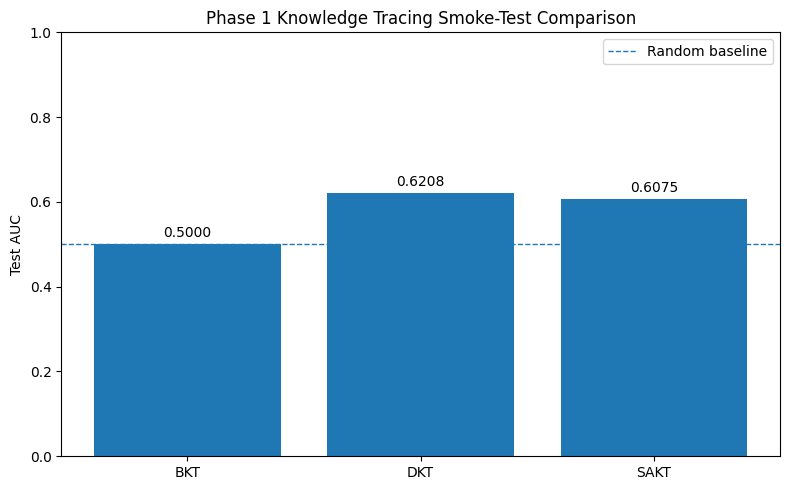

In [ ]:
# Plot model AUC comparison

plot_df = model_comparison_results.dropna(subset=["test_auc"]).copy()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_df["model"],
    plot_df["test_auc"]
)

for bar, value in zip(bars, plot_df["test_auc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

ax.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Test AUC")
ax.set_title("Phase 1 Knowledge Tracing Smoke-Test Comparison")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Compare each model against BKT baseline

if not np.isnan(bkt_auc_value):
    print("Delta from BKT baseline:")

    for _, row in model_comparison_results.iterrows():
        delta = row["test_auc"] - bkt_auc_value

        print(
            f"{row['model']:6s}: "
            f"{'+' if delta >= 0 else ''}{delta:.4f}"
        )
else:
    print("BKT AUC is missing, so deltas cannot be calculated.")

Delta from BKT baseline:
BKT   : +0.0000
DKT   : +0.1208
SAKT  : +0.1075
